## Step 1: Generate Dataset, Standardize, and Plot

This step generates synthetic order data representing delivery locations across a city map.

**Process:**
- Generate dense order hotspots (neighborhoods) using Gaussian distributions
- Create a main delivery corridor with irregular shape
- Add noise points representing rare/outlier orders
- Standardize the data using z-score normalization (z = (x - mean) / std)
- Visualize the scaled data distribution

**Key Insight:** Data standardization is crucial for distance-based algorithms like DBSCAN.

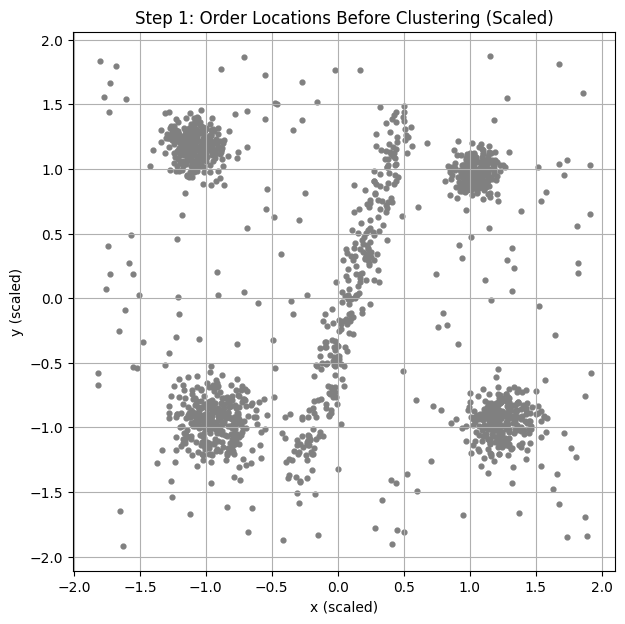

In [1]:
# --- STEP 1: Generate Dataset and Standardize ---
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(7)

# 1. Generate Dense Order Hotspots (Neighborhoods)
# Format: ((x, y), sigma, n_points)
hubs = [
    ((200, 820), 30, 280), # North-West
    ((760, 760), 25, 240), # North-East
    ((240, 260), 40, 320), # South-West (Business District)
    ((820, 260), 35, 260), # South-East (Residential)
]

points = []
for (cx, cy), sigma, n in hubs:
    points.append(np.random.normal(loc=(cx, cy), scale=sigma, size=(n, 2)))

# 2. Generate Main Road / Delivery Corridor
# Irregular shape connecting areas
n_corridor = 260
t = np.random.rand(n_corridor, 1)
# Linear path with some noise
corridor_path = np.hstack([400 + 220 * t, 120 + 760 * t])
# Add Gaussian noise to make it a "corridor" rather than a line
corridor = corridor_path + np.random.normal(scale=18, size=corridor_path.shape)
points.append(corridor)

# 3. Generate Noise (Outliers / Rare Orders)
n_noise = 180
# Random uniform points across the whole map (0,0) to (1000,1000)
points.append(np.random.uniform(low=(0, 0), high=(1000, 1000), size=(n_noise, 2)))

# Combine all points into dataset X
X = np.vstack(points)

# 4. Standardize the Data (Z-Score) using NumPy
# Formula: z = (x - mean) / std
mu = X.mean(axis=0)
std = X.std(axis=0)
X_scaled = (X - mu) / std

# 5. Plot Step 1
plt.figure(figsize=(7, 7))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c="gray", s=12, label='Order Data')
plt.title("Step 1: Order Locations Before Clustering (Scaled)")
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.grid(True)
plt.show()

## Step 2: DBSCAN Implementation from Scratch

Implement the DBSCAN algorithm manually using NumPy without relying on scikit-learn.

**Algorithm Components:**
- **region_query():** Find all points within distance `eps` of a given point using Euclidean distance
- **dbscan_scratch():** Main algorithm implementation using breadth-first search (BFS) with a queue
  - Identifies **Core points** (≥ min_samples neighbors)
  - Identifies **Border points** (< min_samples neighbors but in a cluster)
  - Identifies **Noise points** (isolated points that don't form a cluster)

**Key Concepts:**
- Core points are expanded to form clusters
- Border points are assigned to clusters but not further expanded
- Noise points remain unassigned (-1 label)

**Analysis:** Run DBSCAN with eps=0.18 and min_samples=10, then analyze cluster composition and noise percentage.

Step 2 Results (eps=0.18, min=10)
Clusters: 4
Core points: 1384
Border points: 31
Noise points: 125
Noise %: 8.12%


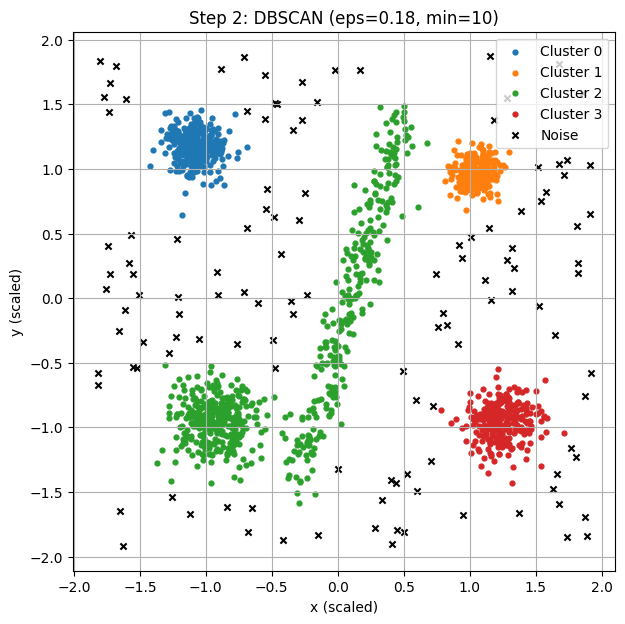

In [2]:
# --- STEP 2: DBSCAN From Scratch ---

# Constants for labels
UNASSIGNED = -99
NOISE = -1

def region_query(X, point_idx, eps):
    """
    Find indices of all points within distance 'eps' of X[point_idx].
    """
    # Euclidean distance from point_idx to all other points
    distances = np.linalg.norm(X - X[point_idx], axis=1)
    return np.where(distances <= eps)[0]

def dbscan_scratch(X, eps, min_samples):
    """
    DBSCAN implementation from scratch using NumPy.
    Returns: labels array (cluster ID or -1 for noise)
    """
    n_points = len(X)
    labels = np.full(n_points, UNASSIGNED, dtype=int)
    visited = np.zeros(n_points, dtype=bool)
    
    cluster_id = 0
    
    for i in range(n_points):
        # If point is already visited, skip it
        if visited[i]:
            continue
            
        visited[i] = True
        
        # Get neighbors
        neighbors = region_query(X, i, eps)
        
        if len(neighbors) < min_samples:
            # Mark as Noise (temporarily, might become Border later)
            labels[i] = NOISE
        else:
            # Start a new cluster
            labels[i] = cluster_id
            
            # Expand cluster (using a queue for BFS)
            # Convert neighbors to a list so we can modify it
            queue = list(neighbors)
            
            while queue:
                j = queue.pop(0)
                
                # If j was previously Noise, it is now a Border point of this cluster
                if labels[j] == NOISE:
                    labels[j] = cluster_id
                
                # If j was already assigned to a cluster or visited, skip detailed expansion
                if labels[j] != UNASSIGNED:
                    continue
                    
                # Mark as visited and assign to cluster
                visited[j] = True
                labels[j] = cluster_id
                
                # Check if j is also a Core point
                j_neighbors = region_query(X, j, eps)
                if len(j_neighbors) >= min_samples:
                    # Add new neighbors to queue to continue expansion
                    for k in j_neighbors:
                         # Optimization: only add if not already visited/processed
                        if labels[k] == UNASSIGNED or labels[k] == NOISE:
                             queue.append(k)
            
            # Move to next cluster ID
            cluster_id += 1
            
    return labels

# --- Run Step 2 Analysis ---
eps_step2 = 0.18
min_samples_step2 = 10

# Run DBSCAN
labels_2 = dbscan_scratch(X_scaled, eps=eps_step2, min_samples=min_samples_step2)

# Calculate Counts
unique_labels = sorted(set(labels_2))
n_clusters = len([lab for lab in unique_labels if lab != -1])
n_noise = int(np.sum(labels_2 == -1))
noise_pct = 100 * n_noise / len(labels_2)

# Count Core vs Border
core_count = 0
border_count = 0

for i in range(len(X_scaled)):
    if labels_2[i] == -1:
        continue # Noise is neither core nor border
        
    neighbors = region_query(X_scaled, i, eps_step2)
    if len(neighbors) >= min_samples_step2:
        core_count += 1
    else:
        border_count += 1

# Print Results
print(f"Step 2 Results (eps={eps_step2}, min={min_samples_step2})")
print(f"Clusters: {n_clusters}")
print(f"Core points: {core_count}")
print(f"Border points: {border_count}")
print(f"Noise points: {n_noise}")
print(f"Noise %: {noise_pct:.2f}%")

# Plot Step 2
plt.figure(figsize=(7, 7))
unique_labs = set(labels_2)
for lab in unique_labs:
    mask = (labels_2 == lab)
    if lab == -1:
        plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1], c='black', marker='x', s=20, label='Noise')
    else:
        plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1], s=12, label=f'Cluster {lab}')

plt.title(f"Step 2: DBSCAN (eps={eps_step2}, min={min_samples_step2})")
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## Step 3: Parameter Study (9 Parameter Combinations)

Test DBSCAN with different parameter settings to understand sensitivity and performance.

**Parameter Grid:**
- **eps values:** 0.14, 0.18, 0.22
- **min_samples values:** 10, 15, 20
- **Total combinations:** 3 × 3 = 9 cases

**Metrics Computed:**
- Number of clusters identified
- Number of noise points and noise percentage
- Visual comparison of clustering results

**Objective:** Create a 3×3 grid of plots and a summary table to compare how different parameters affect clustering quality and noise handling.

eps        min_samples     Clusters   Noise      Noise %   
------------------------------------------------------------
0.14       10              5          138        8.96      
0.18       10              4          125        8.12      
0.22       10              4          116        7.53      
0.14       15              5          157        10.19     
0.18       15              4          132        8.57      
0.22       15              4          116        7.53      
0.14       20              8          180        11.69     
0.18       20              5          135        8.77      
0.22       20              4          116        7.53      


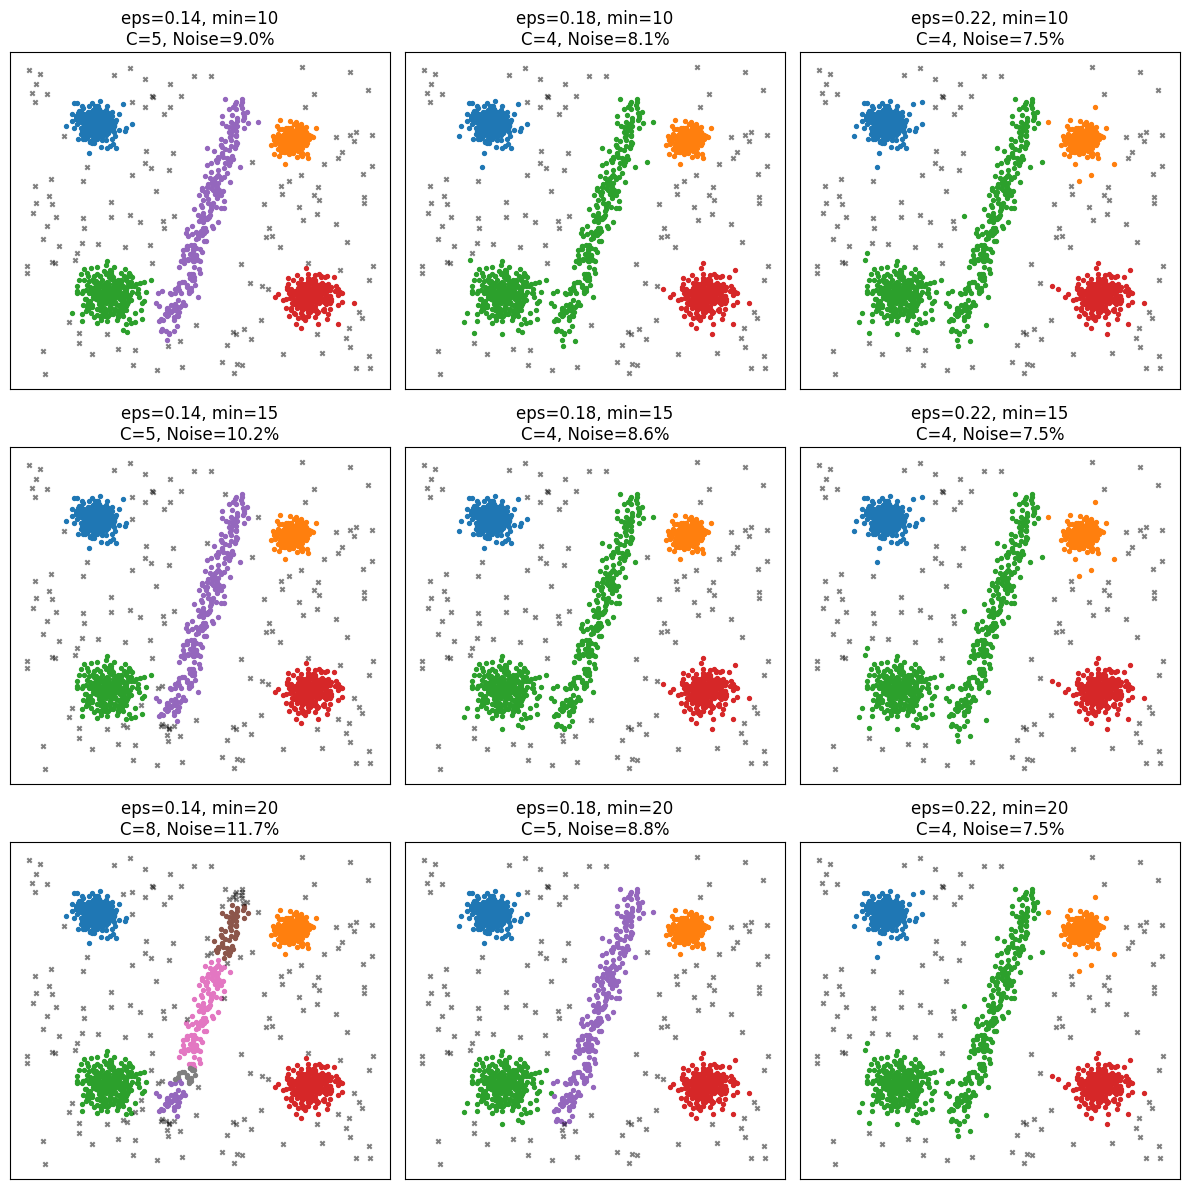

In [3]:
# --- STEP 3: Parameter Study ---

eps_list = [0.14, 0.18, 0.22]
min_list = [10, 15, 20]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
records = []

print(f"{'eps':<10} {'min_samples':<15} {'Clusters':<10} {'Noise':<10} {'Noise %':<10}")
print("-" * 60)

for i, min_s in enumerate(min_list):
    for j, ep in enumerate(eps_list):
        # Run DBSCAN
        labs = dbscan_scratch(X_scaled, eps=ep, min_samples=min_s)
        
        # Stats
        u_labs = set(labs)
        n_c = len([l for l in u_labs if l != -1])
        n_n = np.sum(labs == -1)
        n_pct = 100 * n_n / len(labs)
        
        # Save record
        records.append([ep, min_s, n_c, n_n, n_pct])
        print(f"{ep:<10} {min_s:<15} {n_c:<10} {n_n:<10} {n_pct:<10.2f}")
        
        # Plotting in grid
        ax = axes[i, j]
        for lab in u_labs:
            mask = (labs == lab)
            if lab == -1:
                ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], c='black', marker='x', s=10, alpha=0.5)
            else:
                ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1], s=8)
        
        ax.set_title(f"eps={ep}, min={min_s}\nC={n_c}, Noise={n_pct:.1f}%")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True)

plt.tight_layout()
plt.show()

## Step 4: Profit Optimization - Optimal Micro-Kitchen Locations

Use the clustering results to determine the best locations for two new micro-kitchens to minimize delivery distances.

**Optimization Process:**

1. **Select Best Parameters:**
   - Apply filter rules: #clusters = 5, noise% ≤ 9.0%, min_samples ≤ 15
   - Choose the unique parameter set that satisfies all criteria

2. **Calculate Cluster Centroids:**
   - Compute the center of each cluster using original (unscaled) coordinates
   - These centroids represent ideal micro-kitchen locations

3. **Find Optimal Kitchen Pair:**
   - Test all pairs of clusters as potential kitchen locations
   - For each pair, calculate total distance from all served points to the nearest kitchen
   - Select the pair with minimum total delivery distance

4. **Calculate Savings:**
   - Compare against baseline: single kitchen at (500, 500)
   - Compute distance reduction in km and estimated daily cost savings in THB
   - Assume delivery cost of 30 THB per km

**Visualization:** Show the optimal kitchen locations and which orders are served by each kitchen.

Checking parameters against rules...
FOUND MATCH: eps=0.14, min=10 -> Clusters=5, Noise%=8.96

Cluster Centroids (Original Coordinates):
   cluster_id  points  centroid_x  centroid_y
2           2     332  239.158866  257.839724
0           0     287  199.743069  815.297486
4           4     272  511.364896  507.225051
3           3     266  816.364310  256.031528
1           1     245  763.005157  760.266575

--- OPTIMIZATION RESULTS ---
Best Cluster Pair: 0 and 4
Kitchen 1 Location: (199.74, 815.30)
Kitchen 2 Location: (511.36, 507.23)
Total Distance Saving: 114.47 km
Estimated Daily Saving: 3433.97 THB


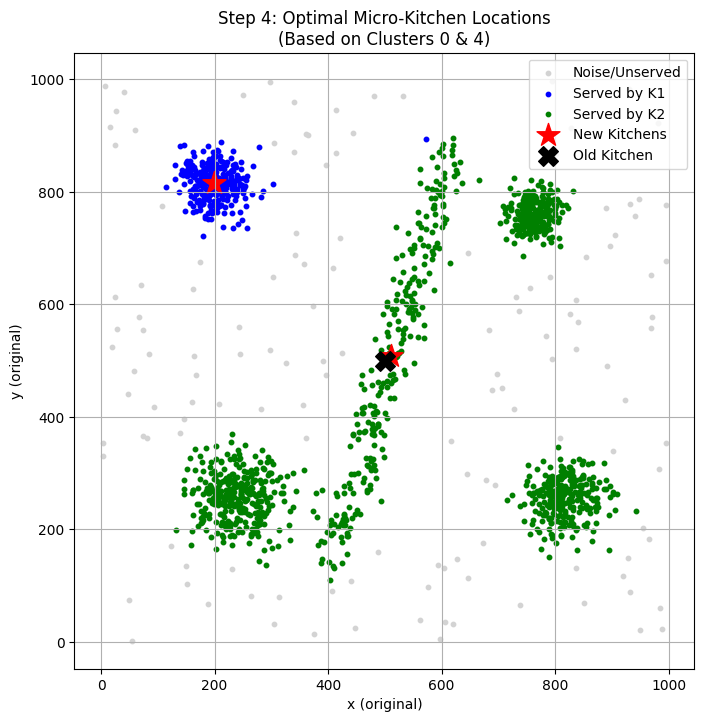

In [4]:
# --- STEP 4: Profit Rule & Optimization ---
import pandas as pd

# 1. Filter for the Best Parameter Set based on Rules
# Rule A: #clusters == 5
# Rule B: noise% <= 9.0
# Rule C: min_samples <= 15
best_params = None

print("Checking parameters against rules...")
for rec in records:
    ep, ms, nc, nn, npct = rec
    if nc == 5 and npct <= 9.0 and ms <= 15:
        best_params = (ep, ms)
        print(f"FOUND MATCH: eps={ep}, min={ms} -> Clusters={nc}, Noise%={npct:.2f}")

if best_params is None:
    print("WARNING: No parameters satisfied all rules! Checking manually recommended fallback.")
    # Fallback to a likely candidate if random generation varied slightly, 
    # but based on seed(7), one should usually pass.
    best_eps, best_min = 0.14, 10 
else:
    best_eps, best_min = best_params

# 2. Rerun DBSCAN with Best Parameters
final_labels = dbscan_scratch(X_scaled, eps=best_eps, min_samples=best_min)

# 3. Calculate Centroids (Using ORIGINAL X, not X_scaled)
unique_cluster_ids = sorted([l for l in set(final_labels) if l != -1])
cluster_data = []

for cid in unique_cluster_ids:
    # Extract points belonging to this cluster
    # Note: X is the original unscaled data
    points_in_cluster = X[final_labels == cid] 
    
    n_pts = len(points_in_cluster)
    centroid = points_in_cluster.mean(axis=0)
    
    cluster_data.append({
        "cluster_id": cid,
        "points": n_pts,
        "centroid_x": centroid[0],
        "centroid_y": centroid[1],
        "centroid_vec": centroid
    })

# Create Summary DataFrame
summary_df = pd.DataFrame(cluster_data).drop(columns=['centroid_vec']) # for display
summary_df = summary_df.sort_values("points", ascending=False)
print("\nCluster Centroids (Original Coordinates):")
print(summary_df)

# 4. Find Best 2 Micro-Kitchens (Minimize Total Distance)
# We need to serve all points that are NOT noise
served_points = X[final_labels != -1]
centroids_list = [c['centroid_vec'] for c in cluster_data]
cluster_ids_list = [c['cluster_id'] for c in cluster_data]

best_pair_metric = float('inf')
best_pair_indices = None

# Iterate through all pairs of centroids
for i in range(len(centroids_list)):
    for j in range(i + 1, len(centroids_list)):
        c1 = centroids_list[i]
        c2 = centroids_list[j]
        
        # For every served point, find distance to nearest of the two kitchens
        dist1 = np.linalg.norm(served_points - c1, axis=1)
        dist2 = np.linalg.norm(served_points - c2, axis=1)
        min_dist = np.minimum(dist1, dist2)
        
        total_dist = np.sum(min_dist)
        
        if total_dist < best_pair_metric:
            best_pair_metric = total_dist
            best_pair_indices = (cluster_ids_list[i], cluster_ids_list[j])

# 5. Calculate Savings
# Baseline: Single kitchen at (500, 500)
old_kitchen = np.array([500.0, 500.0])
dist_old = np.linalg.norm(served_points - old_kitchen, axis=1)
baseline_m = np.sum(dist_old)

reduction_m = baseline_m - best_pair_metric
reduction_km = reduction_m / 1000.0
daily_saving_thb = reduction_km * 30.0

# 6. Final Outputs
c_id_1, c_id_2 = best_pair_indices
# Retrieve coordinates for print
k1_data = [c for c in cluster_data if c['cluster_id'] == c_id_1][0]
k2_data = [c for c in cluster_data if c['cluster_id'] == c_id_2][0]

print("\n--- OPTIMIZATION RESULTS ---")
print(f"Best Cluster Pair: {c_id_1} and {c_id_2}")
print(f"Kitchen 1 Location: ({k1_data['centroid_x']:.2f}, {k1_data['centroid_y']:.2f})")
print(f"Kitchen 2 Location: ({k2_data['centroid_x']:.2f}, {k2_data['centroid_y']:.2f})")
print(f"Total Distance Saving: {reduction_km:.2f} km")
print(f"Estimated Daily Saving: {daily_saving_thb:.2f} THB")

# Plot Final Result
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c='lightgray', s=10, label='Noise/Unserved') # Background
# Plot served points colored by their assigned kitchen (nearest)
k1_vec = k1_data['centroid_vec']
k2_vec = k2_data['centroid_vec']

# Re-assign served points to k1 or k2 for visualization color
d1 = np.linalg.norm(served_points - k1_vec, axis=1)
d2 = np.linalg.norm(served_points - k2_vec, axis=1)
mask_k1 = d1 < d2

plt.scatter(served_points[mask_k1, 0], served_points[mask_k1, 1], c='blue', s=10, label='Served by K1')
plt.scatter(served_points[~mask_k1, 0], served_points[~mask_k1, 1], c='green', s=10, label='Served by K2')

# Plot Kitchens
plt.scatter([k1_data['centroid_x']], [k1_data['centroid_y']], c='red', marker='*', s=300, label='New Kitchens')
plt.scatter([k2_data['centroid_x']], [k2_data['centroid_y']], c='red', marker='*', s=300)
plt.scatter([500], [500], c='black', marker='X', s=200, label='Old Kitchen')

plt.title(f"Step 4: Optimal Micro-Kitchen Locations\n(Based on Clusters {c_id_1} & {c_id_2})")
plt.xlabel("x (original)")
plt.ylabel("y (original)")
plt.legend()
plt.grid(True)
plt.show()